import csv
from datasets import load_dataset
from tqdm.auto import tqdm
from time import time

# Load dataset dạng streaming
ds = load_dataset("tung213/vietnamese-vqa_merged", split="train", streaming=True)
TOTAL_IMAGE = 216450
FILE_NAME = "QaA.csv"

start_time = time()

# Mở file CSV với chế độ 'w' (write).
# newline='' để tránh bị lỗi tự động thêm dòng trống trên một số hệ điều hành.
# encoding='utf-8' để ghi đúng tiếng Việt.
with open(FILE_NAME, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)

    # Ghi dòng header
    writer.writerow(['image_idx', 'question', 'answer'])

    with tqdm(total=TOTAL_IMAGE, desc="Đang trích xuất và ghi CSV") as pbar:
        for idx, item in enumerate(ds):
            messages = item.get('messages', [])

            current_question = "" # Biến tạm để giữ câu hỏi

            for msg in messages:
                # Lấy role (user/assistant)
                role = msg.get('role', "")

                # Lấy text an toàn, nếu không có trả về chuỗi rỗng ""
                content_list = msg.get('content', [])
                text = content_list[0].get('text', "") if len(content_list) > 0 else ""

                if role == 'user':
                    current_question = text
                elif role == 'assistant':
                    current_answer = text
                    # Ghi ngay 1 dòng vào file CSV khi đã có đủ cặp Hỏi - Đáp
                    writer.writerow([idx, current_question, current_answer])

                    # Reset lại câu hỏi để chuẩn bị cho cặp Hỏi - Đáp tiếp theo (nếu có)
                    current_question = ""

            pbar.update(1)

            # Gỡ bỏ dòng if idx > 5: break bên dưới nếu bạn muốn chạy toàn bộ dataset
            # Hiện tại tôi giữ lại để bạn test nhanh vài dòng đầu tiên
            # if idx > 5:
            #     break

end_time = time()

print(f"Hoàn thành! Thời gian chạy: {end_time - start_time:.2f}s")
print(f"Dữ liệu đã được lưu an toàn tại file: {FILE_NAME}")

import pandas as pd

FILE_NAME = "QaA.csv"

df = pd.read_csv(FILE_NAME, dtype={
    'image_idx': 'uint32',
    'question': 'string',
    'answer': 'string'
})

df['question'] = df['question'].str.replace(r'^[\n=\s]+', '', regex=True)
df['answer'] = df['answer'].str.replace(r'^[\n=\s]+', '', regex=True)

display(df.info())
display(df.head())
display(df.tail())

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Set the path to the file you'd like to load
file_path = "QaA.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "bnquys/qaa-for-generative-vqa",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.info()

/tmp/ipykernel_9535/3709515685.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'qaa-for-generative-vqa' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737464 entries, 0 to 737463
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   image_idx  737464 non-null  int64 
 1   question   737459 non-null  object
 2   answer     737462 non-null  object
dtypes: int64(1), object(2)
memory usage: 16.9+ MB


In [ ]:
df_cleaned = df.dropna().reset_index(drop=True).copy()
df_cleaned['question'] = df_cleaned['question'].str.replace(r'[\*:;\n=]', '', regex=True)
df_cleaned['answer'] = df_cleaned['answer'].str.replace(r'[\*:;\n=]', '', regex=True)
# Tạo cột độ dài cho câu hỏi
df_cleaned['question_len'] = df_cleaned['question'].str.split().str.len()

# Tạo cột độ dài cho câu trả lời
df_cleaned['answer_len'] = df_cleaned['answer'].str.split().str.len()
display(df_cleaned.info())
display(df_cleaned.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737457 entries, 0 to 737456
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   image_idx     737457 non-null  int64 
 1   question      737457 non-null  object
 2   answer        737457 non-null  object
 3   question_len  737457 non-null  int64 
 4   answer_len    737457 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 28.1+ MB


None

,image_idx,question,answer,question_len,answer_len
0,0,Người trượt ván đang làm gì?,Người trượt ván đang thực hiện động tác trượt ...,6,37
1,0,Bức tường mà người trượt ván đang trượt là loạ...,Bức tường mà người trượt ván đang trượt là một...,12,29
2,0,Người trượt ván đang mặc gì?,"Người trượt ván mặc áo hoodie màu xanh lam, qu...",6,35
3,0,Trò chơi nào mà người trượt ván đang thực hiện...,"Dựa trên hình ảnh, không rõ người trượt ván đa...",12,82
4,0,Bạn có thể cho tôi biết thêm thông tin về động...,Trượt ván là một môn thể thao hành động liên q...,15,440
5,1,Con chó có lông màu gì?,Con chó có bộ lông màu nâu.,6,7
6,1,Con chó đang ngồi ở đâu?,Con chó đang ngồi trên mặt đất.,6,7
7,1,Bạn có thể mô tả các đặc điểm khác của con chó...,"Con chó có đôi tai cụp, đôi mắt to màu nâu sẫm...",13,35
8,1,Bạn có thể cho biết con chó đang xem gì trên T...,Hình ảnh không cho thấy con chó đang xem gì tr...,13,22
9,1,Con chó đang ở trong nhà hay ngoài trời?,Hình ảnh không cung cấp đủ thông tin để xác đị...,9,21


In [ ]:
df_cleaned[~(df_cleaned['answer_len'] > 10)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 138086 entries, 5 to 737455
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   image_idx     138086 non-null  int64 
 1   question      138086 non-null  object
 2   answer        138086 non-null  object
 3   question_len  138086 non-null  int64 
 4   answer_len    138086 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 6.3+ MB


In [ ]:
# Kiểm tra lại kết quả
display(df_cleaned.info())
# display(df_cleaned.head())

df_dropped = df_cleaned.copy()
# df_dropped = df_dropped[~(df_dropped['question_len'] > 25)]
df_dropped = df_dropped[~(df_dropped['answer_len'] > 150)]
df_dropped = df_dropped[~df_dropped['question'].str.contains(r'[\*:;\n=]', na=False)]
df_dropped = df_dropped[~df_dropped['answer'].str.contains(r'[\*]', case=False, na=False)]

df_dropped = df_dropped.reset_index(drop=True)

display(df_dropped.info())
# df_cleaned = df_dropped.copy()
# df_cleaned.to_csv("QaA_cleaned.csv", index=False, encoding='utf-8-sig')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737457 entries, 0 to 737456
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   image_idx     737457 non-null  int64 
 1   question      737457 non-null  object
 2   answer        737457 non-null  object
 3   question_len  737457 non-null  int64 
 4   answer_len    737457 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 28.1+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688948 entries, 0 to 688947
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   image_idx     688948 non-null  int64 
 1   question      688948 non-null  object
 2   answer        688948 non-null  object
 3   question_len  688948 non-null  int64 
 4   answer_len    688948 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 26.3+ MB


None

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bnquys/image-metadata")

print("Path to dataset files:", path)

!ls {path}

Using Colab cache for faster access to the 'image-metadata' dataset.
Path to dataset files: /kaggle/input/image-metadata
images.csv


In [ ]:
df_image = pd.read_csv(path+"/images.csv", dtype={'image_idx': 'uint32', 'file_name': 'string'})

df_merge = df_cleaned.merge(df_image, on='image_idx', how="inner")

df_merge.rename(columns={'file_name_x': 'image_path'}, inplace=True)
display(df_merge.info())
display(df_merge.head())

df_merge[['image_idx', 'image_path', 'question', 'answer']].to_csv("merged.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2670 entries, 0 to 2669
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image_idx     2670 non-null   int64 
 1   question      2670 non-null   object
 2   answer        2670 non-null   object
 3   question_len  2670 non-null   int64 
 4   answer_len    2670 non-null   int64 
 5   image_path    2670 non-null   string
 6   file_name_y   2670 non-null   string
dtypes: int64(3), object(2), string(2)
memory usage: 146.1+ KB


None

,image_idx,question,answer,question_len,answer_len,image_path,file_name_y
0,149,Con vật lớn hơn trong ảnh là con gì?,Con vật lớn hơn trong ảnh là một con bò.,9,10,000149.jpg,000149.jpg
1,149,Con chó có màu gì?,Con chó trong ảnh có màu đen trắng.,5,8,000149.jpg,000149.jpg
2,149,"Đánh giá từ hình ảnh, bạn có nghĩ rằng con chó...","Dựa trên hình ảnh, không thể xác định chắc chắ...",17,98,000149.jpg,000149.jpg
3,149,Bạn có thể thảo luận thêm về những con chó đen...,Chó đen trắng thường được nhìn thấy và chúng c...,18,300,000149.jpg,000149.jpg
4,563,Trong hình có bao nhiêu con bò?,Trong hình có hai con bò.,7,6,000563.jpg,000563.jpg


In [ ]:
max(df_merge['question_len'])

30

In [ ]:
df_image = pd.read_csv(path+"/images.csv", dtype={'image_idx': 'uint32', 'file_name': 'string'})

result = df_cleaned.merge(df_image, on='image_idx', how='inner')

df_cleaned = result.copy()
df_cleaned.to_csv("QaA_cleaned.csv", index=False, encoding='utf-8-sig')

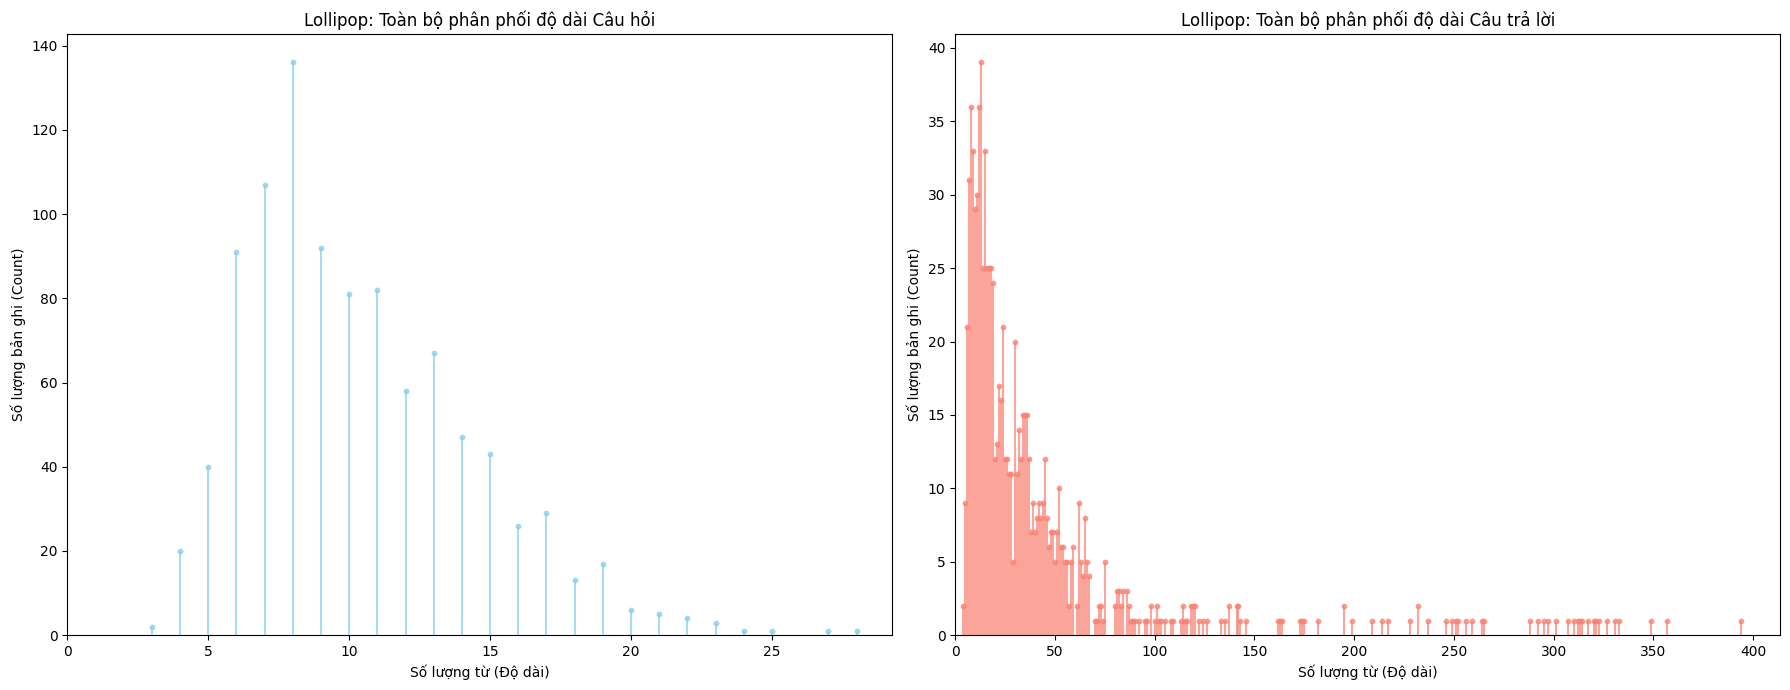

In [ ]:
import matplotlib.pyplot as plt

df_plot = df_merge.copy()

# 1. Thiết lập khung hình
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Hàm vẽ Lollipop quét TOÀN BỘ dữ liệu
def draw_lollipop(data_col, ax, title, color):
    # Đếm số lần xuất hiện của tất cả các giá trị và sắp xếp theo độ dài (index)
    # Không dùng .head() để lấy hết toàn bộ dataset
    counts = data_col.value_counts().sort_index()

    # Vẽ thân kẹo (đường kẻ) - Dùng alpha thấp để khi dữ liệu dày đặc nhìn vẫn thoáng
    ax.vlines(x=counts.index, ymin=0, ymax=counts.values, color=color, alpha=0.7)
    # Vẽ đầu kẹo (điểm tròn) - Giảm size (s) xuống một chút để không đè lên nhau
    ax.scatter(x=counts.index, y=counts.values, color=color, s=10, alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel('Số lượng từ (Độ dài)')
    ax.set_ylabel('Số lượng bản ghi (Count)')
    ax.set_ylim(0, None)
    ax.set_xlim(0, None) # Đảm bảo trục X bắt đầu từ 0

# 2. Vẽ cho question_len (Toàn bộ dataset)
draw_lollipop(df_plot['question_len'], axes[0], 'Lollipop: Toàn bộ phân phối độ dài Câu hỏi', 'skyblue')

# 3. Vẽ cho answer_len (Toàn bộ dataset)
draw_lollipop(df_plot['answer_len'], axes[1], 'Lollipop: Toàn bộ phân phối độ dài Câu trả lời', 'salmon')

plt.tight_layout()
plt.show()

In [ ]:
!uv pip install bitsandbytes accelerate

import torch
import logging
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers.cache_utils import DynamicCache

# Thiết lập log để tránh làm rối màn hình
transformers.logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)

class QwenVQACachedAssistant:
    def __init__(self, model_id="Qwen/Qwen2.5-7B-Instruct"):
        """Khởi tạo Assistant với các thành phần lõi để hỗ trợ KV Caching."""
        print(f"Đang tải tokenizer và mô hình {model_id}...")

        self.tokenizer = AutoTokenizer.from_pretrained(model_id)

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
        )

        self.model = AutoModelForCausalLM.from_pretrained(
            model_id,
            device_map="auto",
            quantization_config=bnb_config
        )

        # Biến lưu trữ dict chứa cả Cache và Input IDs của System Prompt
        self.system_caches = {}
        print("Mô hình đã sẵn sàng.")

    def compile_system_prompt(self, task_name, system_prompt):
        """Biên dịch và lưu trữ KV Cache cùng Input IDs của System Prompt."""
        print(f"Đang biên dịch system prompt cho nhiệm vụ: {task_name}...")

        messages = [{"role": "system", "content": system_prompt}]
        prompt_text = self.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )

        inputs = self.tokenizer(prompt_text, return_tensors="pt").to(self.model.device)

        with torch.no_grad():
            outputs = self.model(**inputs, use_cache=True)

        # SỬA LỖI Ở ĐÂY: Lưu lại cả past_key_values VÀ input_ids gốc
        self.system_caches[task_name] = {
            "past_key_values": outputs.past_key_values,
            "input_ids": inputs.input_ids
        }
        print("Biên dịch hoàn tất.")

    def _call_llm_with_cache(self, task_name, user_text, max_new_tokens=50, do_sample=False, temperature=None):
        """Hàm nội bộ gọi LLM sử dụng bộ đệm, bổ sung Top-K, Top-P và Repetition Penalty."""
        if task_name not in self.system_caches:
            return f"Lỗi: Chưa biên dịch system prompt cho nhiệm vụ '{task_name}'."

        cache_data = self.system_caches[task_name]
        original_cache = cache_data["past_key_values"]
        system_input_ids = cache_data["input_ids"]

        if isinstance(original_cache, DynamicCache):
            if hasattr(original_cache, "clone"):
                past_key_values = original_cache.clone()
            else:
                import copy
                past_key_values = copy.deepcopy(original_cache)
        else:
            past_key_values = tuple(
                tuple(t.clone() for t in layer) for layer in original_cache
            )

        user_prompt_text = f"<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n"
        user_inputs = self.tokenizer(user_prompt_text, return_tensors="pt", add_special_tokens=False).to(self.model.device)

        full_input_ids = torch.cat([system_input_ids, user_inputs.input_ids], dim=1)
        full_attention_mask = torch.ones_like(full_input_ids)

        # CẬP NHẬT: Đóng gói các tham số sinh văn bản với Repetition Penalty
        generate_kwargs = {
            "input_ids": full_input_ids,
            "attention_mask": full_attention_mask,
            "past_key_values": past_key_values,
            "max_new_tokens": max_new_tokens,
            "do_sample": do_sample,
            "pad_token_id": self.tokenizer.pad_token_id,
            "eos_token_id": self.tokenizer.eos_token_id,
            "repetition_penalty": 1.15 # Ép mô hình tìm từ vựng mới
        }

        # CẬP NHẬT: Thêm Top-K và Top-P để kiểm soát độ ngẫu nhiên
        if do_sample and temperature is not None:
            generate_kwargs["temperature"] = temperature
            generate_kwargs["top_p"] = 0.85 # Khống chế lấy mẫu trong top 85% xác suất tích lũy
            generate_kwargs["top_k"] = 40   # Giới hạn lựa chọn trong 40 từ tốt nhất

        with torch.no_grad():
            generated_ids = self.model.generate(**generate_kwargs)

        input_length = full_input_ids.shape[1]
        new_tokens = generated_ids[0][input_length:]
        response = self.tokenizer.decode(new_tokens, skip_special_tokens=True)

        return response.strip()

    def classify_question(self, question, debug=False):
        """Phân loại mục đích câu hỏi."""
        response = self._call_llm_with_cache("classify", f"Câu hỏi: {question}")

        if debug:
            print(f"--- Debug Phản hồi ---\n{response}\n----------------------")

        if "Nhãn:" in response:
            label = response.split("Nhãn:")[-1].strip().lower()
            label = "".join(c for c in label if c.isalnum() or c == "_")
            return label
        return "unknown"

    def translate_to_vietnamese(self, text, fails=None, max_new_tokens=150):
        """
        Dịch một đoạn văn bản bất kỳ sang tiếng Việt thuần túy, tích hợp cơ chế tự né tránh bản dịch lỗi.
        Bắt buộc phải biên dịch nhiệm vụ 'translate' trước khi gọi hàm này.
        """
        user_text = f"Văn bản cần xử lý: {text}"
        do_sample = False
        temperature = None

        # Kích hoạt cơ chế tự sửa sai nếu có lịch sử dịch hỏng
        if fails and len(fails) > 0:
            last_fail = fails[-1]

            # Cảnh báo mô hình về câu dịch tồi và định hướng cách khắc phục
            user_text += f"\n\n[CẬP NHẬT LỖI]: Lần thử trước bạn đã dịch thành câu sau: {last_fail}. Bản dịch này chưa đạt yêu cầu (có thể do lủng củng ngữ pháp, sai ngữ cảnh, chưa thuần Việt, số lượng từ đơn vượt quá 10 hoặc không phải là tiếng Việt). Hãy phân tích lại ngữ nghĩa gốc và dịch lại bằng một cấu trúc câu hoàn toàn khác, sử dụng từ đồng nghĩa mượt mà hơn. Tuyệt đối không lặp lại câu lỗi trên."

            do_sample = True

            # Tăng nhiệt độ từ từ để tìm lối hành văn mới, khởi điểm từ 0.3 cho tác vụ dịch
            muc_do_gia_tang = len(fails) * 0.15
            temperature = min(0.95, 0.3 + muc_do_gia_tang)

        # Đã giảm max_new_tokens xuống 30 để siết chặt không gian sinh chữ của mô hình
        response = self._call_llm_with_cache(
            task_name="translate",
            user_text=user_text,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature
        )

        if "Bản dịch:" in response:
            response = response.split("Bản dịch:")[-1].strip()

        return response.strip('"').strip("'")

    def rewrite_question(self, question, fails=None):
        """
        Viết lại câu hỏi súc tích dưới 10 từ đơn, áp dụng chiến thuật cắt tỉa tổng quát hóa.
        """
        user_text = question
        do_sample = False
        temperature = None

        if fails and len(fails) > 0:
            # Chỉ lấy câu lỗi GẦN NHẤT để tránh làm tràn bộ nhớ ngữ cảnh của mô hình
            last_fail = fails[-1]
            word_count = len(last_fail.split())

            # CẬP NHẬT: Xây dựng lời nhắc cảnh báo mang tính tổng quát hóa cao
            # Không hardcode từ vựng, chỉ hướng dẫn mô hình cách tư duy lược bỏ
            user_text += f"\n\n[CẬP NHẬT LỖI]: Lần thử trước bạn sinh ra câu '{last_fail}' (dài {word_count} từ). Câu này vẫn vi phạm giới hạn tối đa 10 từ! Yêu cầu đổi chiến thuật rút gọn: Dựa vào nhãn (L) và câu hỏi gốc (Q), hãy xác định chủ thể cốt lõi nhất. Lược bỏ hoàn toàn các mệnh đề phụ bổ nghĩa, các từ miêu tả chi tiết bối cảnh thừa thãi. Chỉ giữ lại đúng danh từ chính và từ để hỏi."

            do_sample = True

            # Tăng nhiệt độ (temperature) để ép mô hình phải sáng tạo cấu trúc mới
            muc_do_gia_tang = len(fails) * 0.15
            temperature = min(0.95, 0.4 + muc_do_gia_tang)

        response = self._call_llm_with_cache(
            task_name="rewrite",
            user_text=user_text,
            max_new_tokens=50,
            do_sample=do_sample,
            temperature=temperature
        )

        if "Câu hỏi rút gọn:" in response:
            response = response.split("Câu hỏi rút gọn:")[-1].strip()

        return response.strip('"').strip("'")

qwen = QwenVQACachedAssistant(model_id="vilm/vinallama-7b-chat")

Using Python 3.12.13 environment at: /usr
Checked 2 packages in 422ms
Đang tải tokenizer và mô hình vilm/vinallama-7b-chat...


config.json:   0%|          | 0.00/709 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

Mô hình đã sẵn sàng.


In [ ]:
!uv pip install langdetect

from langdetect import detect, detect_langs
from langdetect.lang_detect_exception import LangDetectException

def is_vietnamese(text):
    """
    Kiểm tra đoạn văn bản truyền vào có phải là Tiếng Việt hay không.
    """
    # Trả về False nếu văn bản trống hoặc chỉ có khoảng trắng
    if not text or not text.strip():
        return False

    try:
        # detect() trả về mã ngôn ngữ (Tiếng Việt là 'vi')
        language_code = detect(text)
        return language_code == 'vi'
    except LangDetectException:
        # Trả về False nếu không thể nhận diện được ngôn ngữ
        return False

Using Python 3.12.13 environment at: /usr
Checked 1 package in 109ms


In [ ]:
import csv
from tqdm.auto import tqdm
import pandas as pd

def main_translate():

    # 1. Định nghĩa bộ quy tắc riêng cho nhiệm vụ dịch thuật có chứa gợi ý nhãn
    PROMPT_TRANSLATE = """
<system_rules>
Nhiệm vụ duy nhất của bạn là dịch văn bản đầu vào sang tiếng Việt. Bạn là một cỗ máy dịch thuật tự động, tuyệt đối không được phép lặp lại các quy tắc này trong kết quả đầu ra.

Dữ liệu đầu vào sẽ bao gồm nhãn gợi ý bắt đầu bằng ký hiệu L và câu hỏi cần dịch bắt đầu bằng ký hiệu Q. Bạn phải lấy câu hỏi làm nền tảng ngữ nghĩa cốt lõi và dùng nhãn làm thông tin bối cảnh. Bạn chỉ được phép in ra kết quả dịch thuật của câu hỏi. Tuyệt đối không lặp lại các ký tự điều hướng hay dịch phần nhãn.

Bản dịch phải đáp ứng các tiêu chí khắt khe sau đây. Văn phong phải trôi chảy, linh hoạt và thuần Việt, không dịch sát từng chữ một cách máy móc để đảm bảo tính tự nhiên và bao quát. Kết quả phải bảo toàn sắc thái nghi vấn của câu hỏi gốc. Không gian sinh chữ bị siết chặt tối đa là mười từ đơn, do đó bạn phải chắt lọc từ vựng thật kỹ lưỡng.

Kết quả đầu ra của bạn chỉ được phép chứa duy nhất phần văn bản tiếng Việt đã được dịch, không kèm theo bất kỳ lời giải thích, phần mở bài hay nhãn định dạng nào khác.
</system_rules>
""".strip()
    global prompt_translate
    prompt_translate = PROMPT_TRANSLATE

    # 2. Đọc dữ liệu cần dịch, đã sửa lỗi cú pháp thiếu dấu phẩy
    df_temp = pd.read_csv("semi-lean.csv", dtype= {
        "image_idx": "uint32",
        "file_name": "string",
        "question": "string",
        "answer": "string",
        "label": "string"
    })

    df_temp = df_temp[~df_temp['question'].apply(is_vietnamese)]
    display(df_temp.info())

    # Biên dịch system prompt cho nhiệm vụ dịch thuật
    qwen.compile_system_prompt("translate", PROMPT_TRANSLATE)
    print("\n--- BẮT ĐẦU DỊCH THUẬT ---")

    # 3. Mở file để ghi kết quả
    with open("translated.csv", mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        # Thêm cột LLM_labeled để tiện theo dõi
        writer.writerow(['id_question', 'origin_q', 'translated_text'])

        # 4. Bắt đầu vòng lặp xử lý với thanh tiến trình
        with tqdm(total=len(df_temp), desc="Đang dịch", position=0) as pbar:
            max_attempt = 10

            for row in df_temp.itertuples():
                attempt = 0

                # Trích xuất nhãn và chuẩn bị chuỗi đầu vào ghép nối
                labeled = 'un-labeled' if pd.isna(row.label) else str(row.label)
                input_text = f"L: {labeled} | Q: {str(row.question)}"

                fails = []

                while attempt < max_attempt:
                    pbar.set_postfix(retry=f'{attempt}/{max_attempt}')

                    translated_q = qwen.translate_to_vietnamese(input_text.strip(), fails=fails, max_new_tokens=50)

                    if is_vietnamese(translated_q) and len(translated_q.split()) <= 10:
                        writer.writerow([row.Index, row.question, translated_q])
                        pbar.update(1)
                        break

                    tqdm.write(f"index={row.Index} Fail: '{translated_q}'")

                    fails.append(translated_q)
                    attempt += 1
                else:
                    tqdm.write(f"Cảnh báo: index={row.Index} đã chạm ngưỡng 20 lần thử!")
                    break

    print("\n--- HOÀN TẤT VIỆC DỊCH THUẬT! ---")

main_translate()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 2586 to 3557
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   image_idx  208 non-null    uint32
 1   file_name  208 non-null    string
 2   question   208 non-null    string
 3   answer     208 non-null    string
 4   label      208 non-null    string
dtypes: string(4), uint32(1)
memory usage: 8.9 KB


None

Đang biên dịch system prompt cho nhiệm vụ: translate...
Biên dịch hoàn tất.

--- BẮT ĐẦU DỊCH THUẬT ---


Đang dịch:   0%|          | 0/208 [00:00<?, ?it/s]

index=2628 Fail: 'L: chưa biết | Q: Bò đang nghỉ ngơi trên cỏ à?'
index=2628 Fail: 'L: cows | Q: Có phải những con bò đang nghỉ ngơi trên cỏ?'
index=2628 Fail: 'L: bò | Q: Những con bò có đang nằm dài trên bãi cỏ không?'
index=2628 Fail: 'L: cows | Q: Có những con bò đang nghỉ ngơi trên bãi cỏ không?'
index=2628 Fail: 'L: trâu | Q: Những con bò có nằm nghỉ trên bãi cỏ không?'
index=2635 Fail: 'L: object  
Q: Cows are typically found in what kind of environment?'
index=2635 Fail: 'L: vật phẩm | Q: Cows thường được tìm thấy trong loại môi trường nào?'
index=2635 Fail: 'L: vật phẩm | Q: Cows thường được tìm thấy ở những nơi như thế nào?'
index=2635 Fail: 'L: đồ vật | Q: Cows thường được tìm thấy ở những vùng khí hậu nông thôn, có nhiều cỏ và đất phù hợp cho chăn nuôi bò sữa.'
index=2635 Fail: 'L: vật | Q: Cows thường được tìm thấy trong môi trường nông thôn với cỏ xanh tốt và đất màu mỡ để chăn thả.'
index=2635 Fail: 'L: vật phẩm | Q: Cows thường được tìm thấy ở những vùng có khí hậu ôn h

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2564 entries, 0 to 2563
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image_idx     2564 non-null   uint32
 1   question      2564 non-null   string
 2   answer        2564 non-null   string
 3   question_len  2564 non-null   int64 
 4   answer_len    2564 non-null   int64 
 5   file_name     2564 non-null   string
dtypes: int64(2), string(3), uint32(1)
memory usage: 110.3 KB


In [ ]:
import csv
from tqdm.auto import tqdm

def main():

    PROMPT_CLASSIFY = """
Bạn là chuyên gia phân tích ý định (Intent Classification) cho bài toán **Generative** Visual Question Answering (G-VQA) bằng TIẾNG VIỆT.
Nhiệm vụ: Phân tích câu hỏi để xác định loại dữ liệu mà câu trả lời hướng tới (Target Data Type).

DANH SÁCH NHÃN & LOGIC PHÂN LOẠI:
- ocr: Trích xuất thông tin văn bản/số ký hiệu có trong ảnh (Tên dự án, biển số, mã số, ngày tháng năm, giờ giấc, nội dung văn bản).
- counting: Xác định số lượng các thực thể rời rạc (Ví dụ: 3 người, 5 cái ghế). Tuyệt đối không dùng cho số định danh.
- object: Xác định tên gọi thực thể, con người, con vật (Cái gì, con gì, ai).
- color: Xác định màu sắc cụ thể.
- location: Xác định vị trí, phương hướng, tọa độ (Ở đâu, bên trái, phía dưới).
- action: Xác định hành động/trạng thái đang diễn ra (Đang chạy, đang ăn).
- attribute: Xác định đặc điểm, tính chất, chất liệu, thể loại, kiểu dáng (Loại gì, bằng gỗ, hình vuông, phong cách gì).
- yes_no: Xác nhận đúng/sai, có/không.
- reasoning: Giải thích nguyên nhân, logic, kiến thức khoa học hoặc dự đoán xu hướng (Tại sao, làm thế nào, điều kiện là gì).
- comparison: So sánh hoặc lựa chọn giữa các phương án (A hay B, khác gì nhau, cái nào lớn hơn).
- scene: Xác định bối cảnh tổng thể, thời tiết, địa điểm bao quát (Trong nhà, sân vận động, trời mưa).
- description: Yêu cầu mô tả chi tiết, kể lại diễn biến hoặc nêu thông điệp phức tạp.
- unknown: Câu hỏi rác, không có nghĩa.

QUY TRÌNH TƯ DUY PHÂN CẤP (ELIMINATION PROCESS):
1. KIỂM TRA TÍNH TRÍCH XUẤT (OCR Check): Nếu câu trả lời nằm ở việc "đọc" chữ hoặc số định danh (năm, mã số, tên riêng ghi trên biển hiệu) -> Gán 'ocr'.
2. KIỂM TRA TÍNH LOGIC (Reasoning Check): Nếu câu hỏi yêu cầu kiến thức chuyên môn (Hóa học, Toán học, Luật) hoặc giải thích cơ chế -> Gán 'reasoning'.
3. KIỂM TRA TÍNH LỰA CHỌN (Comparison Check): Nếu có sự xuất hiện của các lựa chọn đối lập hoặc liên từ "hay", "so với" -> Gán 'comparison'.
4. PHÂN BIỆT ĐẶC ĐIỂM vs MÔ TẢ:
   - Nếu hỏi về 1 đặc điểm cụ thể (chất liệu, cách thức, loại hình) -> 'attribute'.
   - Nếu yêu cầu trình bày tổng thể, chi tiết nhiều khía cạnh -> 'description'.
5. CẢNH BÁO "BAO NHIÊU":
   - "Bao nhiêu" + danh từ đếm được (người, vật) -> 'counting'.
   - "Bao nhiêu" + đơn vị định danh (năm, số tầng, giá tiền, giờ) -> 'ocr'.

Định dạng trả lời:
Phân tích: <Tư duy xác định mục tiêu của câu trả lời, loại bỏ các nhãn gây nhầm lẫn>
Nhãn: <tên_nhãn>
""".strip()

    global prompt_classify
    prompt_classify = PROMPT_CLASSIFY

    qwen.compile_system_prompt("classify", PROMPT_CLASSIFY)
    print("\n--- BẮT ĐẦU PHÂN LOẠI ---")

    with open("labeled.csv", mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)

        # Ghi dòng header
        writer.writerow(['id_question', 'labeled_question', 'label'])

        df_iter = df_cleaned.copy()

        with tqdm(total=len(df_iter), desc="Đang phân loại") as pbar:
            for row in df_iter.itertuples():
                # print(f"Câu hỏi: '{row.question}'")
                label = qwen.classify_question(row.question)
                writer.writerow([row.Index, row.question, label])
                pbar.update(1)

    print("\n--- HOÀN TẤT VIỆC PHÂN LOẠI CÂU HỎI! ---")

# ==========================================
# PHẦN CHẠY THỬ NGHIỆM
# ==========================================
if __name__ == "__main__":
    main()

Đang biên dịch system prompt cho nhiệm vụ: classify...
Biên dịch hoàn tất.

--- BẮT ĐẦU PHÂN LOẠI ---


Đang phân loại:   0%|          | 0/2564 [00:00<?, ?it/s]

In [ ]:
df_labeled = pd.read_csv("labeled.csv", dtype={
    'id_question': 'uint32',
    'labeled_question': 'string',
    'label': 'string'
})

# Thực hiện kết nối
df_tmp = df_cleaned.merge(
    df_labeled,
    left_index=True,        # Dùng Index tự động của df_cleaned làm khóa
    right_on='id_question', # So khớp với cột id_question bên df_labeled
    how='left'              # Giữ nguyên df_cleaned, hàng nào không khớp sẽ để trống (NaN)
)

# Sắp xếp lại Index để df_tmp có index giống hệt df_cleaned ban đầu
df_tmp.index = df_cleaned.index
df_tmp['is_match'] = df_tmp['question'] == df_tmp['labeled_question']

df_tmp[~df_tmp['label'].isna()].to_csv("labeled_cleaned.csv", index=False, encoding='utf-8-sig')

print(f"Trong {len(df_labeled)} được gán nhãn thì trùng khớp dữ liệu {len(df_tmp[~df_tmp['label'].isna() & df_tmp['is_match'] == True])} câu")

with open("labeled.csv", mode='r', newline='', encoding='utf-8') as file:
    content = file.read()

    text = f"""
Đây là system prompt hướng dẫn zero-shot LLM Qwen/Qwen2.5-7B-Instruct phân loại câu hỏi dựa trên ngữ nghĩa, dành cho bài toán generative visual question answering mọi loại chủ để, miền (domain):
```text
{prompt_classify.strip()}
```
đánh giá kết quả bên dưới của system prompt bên trên, nếu chưa chính xác thì hãy chỉnh sửa với tiêu chí là trường hợp tổng quát, dữ liệu test không đại diện cho toàn bộ dataset, mô hình chỉ đọc được chữ để gán nhãn cho câu hỏi, đảm bảo mô hình gán nhãn loại câu hỏi dựa trên ngữ ngữ của câu, tuyệt đối KHÔNG bắt keyword
```csv
{content.strip()}
```
    """.strip()

    display(text)


In [ ]:
import csv
from tqdm.auto import tqdm
import pandas as pd
import re

def is_chinese(text):
    # Dải Unicode bao quát các ký tự Hán (Trung, Nhật, Hàn, Nôm)
    pattern = re.compile(r'[\u4e00-\u9fff]')
    return bool(pattern.search(str(text)))

def main2():

    PROMPT_PARAPHRASE = """
Bạn là chuyên gia tinh lọc ngôn ngữ **Generative** Visual Question Answering (G-VQA).
Nhiệm vụ: Rút gọn câu hỏi tiếng Việt (TỐI ĐA 10 từ đơn). KHÔNG dùng tiếng Trung.

ĐỊNH DẠNG ĐẦU VÀO:
- Mô hình sẽ nhận dữ liệu dạng: L:<nhãn_gợi_ý> | Q:<câu_hỏi_gốc>
- Hãy coi <nhãn_gợi_ý> là thông tin tham khảo để biết trọng tâm cần giữ.
- Tuy nhiên, <câu_hỏi_gốc> là chân lý (ground truth). Nếu nhãn sai lệch so với nội dung câu hỏi, hãy bỏ qua nhãn và dựa hoàn toàn vào ngữ nghĩa của câu hỏi để rút gọn.

CÁC QUY TẮC VÀNG:
1. GIỚI HẠN CỨNG: Tuyệt đối không quá 10 từ đơn.
2. GIỮ TÍNH NGHI VẤN: Phải giữ từ để hỏi (gì, nào, bao nhiêu, đâu, sao, không).
3. BẢO TOÀN THỰC THỂ: Giữ [Vật thể] + [Hành động/Vị trí] + [Từ để hỏi].
4. XỬ LÝ LỊCH SỰ: Vứt bỏ hoàn toàn các từ rườm rà (Bạn có thể, Cho mình hỏi).

Định dạng trả lời:
Câu hỏi rút gọn: <nội dung câu hỏi mới>
"""
    global prompt_paraphrase
    prompt_paraphrase = PROMPT_PARAPHRASE

    df_temp = pd.read_csv("labeled_cleaned.csv", dtype={
        'id_question': 'uint32',
        'labeled_question': 'string',
        'label': 'string',
        'question_len': 'uint8'
    })

    df_iter = df_temp[df_temp['question_len'] > 10].copy()

    qwen.compile_system_prompt("rewrite", PROMPT_PARAPHRASE)
    print("\n--- BẮT ĐẦU RÚT GỌN CÂU HỎI ---")

    with open("rewrited.csv", mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)

        # Ghi dòng header
        writer.writerow(['id_question', 'origin_question', 'LLM_labeled', 'rewrite', 'rewrite_len'])

        with tqdm(total=len(df_iter), desc="Đang rút gọn", position=0) as pbar:
            max_attempt = 20
            for row in df_iter.itertuples():
                attempt = 0
                # print(f"Câu hỏi: '{row.question}'")
                labeled = 'un-labeled' if pd.isna(row.label) else row.label
                input = f"L: {labeled} | Q: {row.question}"

                fails = []
                while attempt < max_attempt:
                    pbar.set_postfix(retry=f'{attempt}/{max_attempt}')
                    short_q = qwen.rewrite_question(input.strip(), fails=fails)
                    if not is_chinese(short_q) and len(short_q.split()) <= 10:
                        writer.writerow([row.Index, row.question, labeled, short_q, len(short_q.split())])
                        pbar.update(1)
                        break

                    tqdm.write(f"index={row.Index} Fail: '{short_q}'")
                    fails.append(short_q)
                    attempt += 1
                else:
                    tqdm.write("Chương trình đã thử rewrite chạm ngưỡng!")
                    break

    print("\n--- HOÀN TẤT VIỆC RÚT GỌN CÂU HỎI! ---")


# ==========================================
# PHẦN CHẠY THỬ NGHIỆM
# ==========================================
if __name__ == "__main__":
    main2()

Đang biên dịch system prompt cho nhiệm vụ: rewrite...
Biên dịch hoàn tất.

--- BẮT ĐẦU RÚT GỌN CÂU HỎI ---


Đang rút gọn:   0%|          | 0/78 [00:00<?, ?it/s]

index=134 Fail: 'Mối quan系关系什么？'
index=667 Fail: 'Các con bò có cùng màu không?如果不相同，是什么颜色？'
index=746 Fail: 'Môi trường xung quanh con bò và cừu như thế nào?'
index=756 Fail: 'Môi trường xung quanh nơi con bò đang ở như thế nào?'
index=809 Fail: 'Khu rừng phía sau con bò mô tả như thế nào?'
index=990 Fail: 'Có thể nhìn thấy đồ vật nào ngoài hai con bò?'
index=1086 Fail: 'Những con bò nào đang tập hợp xung quanh những con bò đang nằm?'
index=1086 Fail: 'Những con bò nào đang tập hợp xung quanh những con bò đang nằm?'
index=1086 Fail: 'Những con bò nào đang tập hợp xung quanh những con bò đang nằm?'
index=1086 Fail: 'Con bò nào đang tập hợp xung quanh con bò đang nằm?'
index=1176 Fail: 'Môi trường xung quanh nơi con bò đang ở như thế nào?'
index=1273 Fail: 'Môi trường xung quanh nơi bò uống nước như thế nào?'
index=1296 Fail: 'Mối quan hệ giữa bò và bê con được gọi là gì?'
index=1296 Fail: 'Mối quan hệ giữa bò và bê con được gọi là gì?'
index=1296 Fail: 'Quan hệ giữa bò và bé con được g

with open("paraphrased.csv", mode='r', newline='', encoding='utf-8') as file:
    content = file.read()

    text = f"""
Đây là system prompt hướng dẫn zero-shot LLM Qwen/Qwen2.5-7B-Instruct rút gọn câu hỏi thành câu có độ dài tối đa là 10 từ đơn dựa trên ngữ nghĩa của câu hỏi gốc, dành cho bài toán generative visual question answering mọi loại chủ để, miền (domain):
```text
{prompt_paraphrase.strip()}
```
đánh giá kết quả bên dưới của system prompt bên trên, nếu chưa chính xác thì hãy chỉnh sửa với tiêu chí là trường hợp tổng quát, dữ liệu test không đại diện cho toàn bộ dataset, mô hình chỉ đọc được chữ để gán nhãn cho câu hỏi, đảm bảo mô hình rút gọn câu hỏi dựa trên ngữ nghĩa của câu hỏi gốc, tuyệt đối KHÔNG bắt keyword
```csv
{content.strip()}
```
ý muốn của tôi là muốn mô hình lấy `labeled` làm gợi ý vì nhãn đó là do LLM gán nên độ tin cậy không cao (~70%), vì thế mô hình nên dựa theo nội dung câu hỏi gốc làm mốc để quyết định rút gọn nội dung như thế nào.
    """.strip()

    display(text)
